In [1]:
# Main file to calibrate the Maréchal approximation for the NGS mode
# 
# The reference file is ./config/GPAO_NGS_VIS.ini
#
# The script loops the TIPTOP function 'overallSimulation' on the
# physical different parameters to find the coefficient of their
# dependency
# 
# Created: 09/19/2023 (mm/dd/yyyy)
# Modified: 06/06/2023 (mm/dd/yyyy)
#   - Changing the convention of the parameter vector
# Author: Anthony Berdeu (LESIA - Observatoire de Paris)
#####################################################################

In [2]:
# IMPORTING LIBRARIES #
#######################

# Python
import os
import numpy as np
import configparser

# ASPRO and tiptop
import aspro as aspro
import fit_tiptop as fit_tiptop

Cupy import failed. P3 will fall back to CPU use.
Cupy import failed. MASTSEL will fall back to CPU use.
Cupy import failed. SEEING will fall back to CPU use.


In [3]:
# PARAMETERS #
##############

# Mode to calibrate
flag_mode = 'NGS_VIS' # NGS_VIS/NGS_IR
name_config = 'GPAO_' + flag_mode

# Global paths
path = os.getcwd() + '/'
path_config_0 = path + 'config_0/'
path_results = path + 'results/Maréchal_calibration/' + flag_mode + '/'


# Default parameters
lambda_sci = 2.2e-06 # Wavelength of the science channel (m)

# # Wavelength of the HO NGS channel (m)
# Convertion magnitude to flux / Magnitude 0-point (ph/s/m2 for mag=0)
# Number of corrected modes corrected models (to compute the equivalent DM number of actuators)
# Loop frequency
if flag_mode[4:7] == 'VIS':
    lambda_ngs = 750e-9
    mag2flux = 2.63e10
    n_mode_AO = 800
    f_loop = 1000.0
elif flag_mode[4:7] == 'IR':
    lambda_ngs = 2.2e-6
    mag2flux = 1.66e9
    n_mode_AO = 44
    f_loop = 500.0
else:
    raise ValueError(flag_mode + \
        ' -> Unknown mode (*_VIS / *_IR)')   

r_0 = 0.100 # Fried's parameter @500 nm (m?)
v_0 = 25.0 # Wind speed of the turbulence layer (m.s-1)
h_0 = 10000.0 # Altitude of the turbulent layer (m)

g_loop = 0.5 # Loop gain
sigRON = 0.2 # Readout noise of the camera

mag_ngs = 8 # Magnitude of the NGS
zenith_angle = 0
theta_sci = 0 # Added to the zenith_angle

WFS_transmission = 0.3 # Global transmission of the WFS channel



In [4]:
# PREPARING DEFAULT CONFIGURATION #
###################################

##### Miscellaneous #####
# Secant of the zenith angle
airmass = 1/np.cos(np.radians(zenith_angle))
##### Miscellaneous #####

##### Creating folders #####
if not os.path.exists(path_results):
    os.makedirs(path_results)
##### Creating folders #####

###### Opening default configuration ######
config_0 = configparser.ConfigParser()
config_0.optionxform = str # Needed to be case sensitive
config_0.read(path_config_0 + name_config + '.ini')
###### Opening default configuration ######

###### Updating config ######
# Atmosphere
config_0['atmosphere']['Seeing'] = '%f'%(aspro.r02seeing(r_0))
config_0['atmosphere']['Cn2Heights'] = '[%f]'%(h_0)
config_0['atmosphere']['WindSpeed'] = '[%f]'%(v_0)

# Wavelength
config_0['sources_HO']['Wavelength'] = '[%e]'%(lambda_ngs)
config_0['sources_science']['Wavelength'] = '[%e]'%(lambda_sci)

# Angle
config_0['telescope']['ZenithAngle'] = '%f'%(zenith_angle)
config_0['sources_HO']['Zenith'] = '[%f]'%(0)
config_0['sources_science']['Zenith'] = '[%f]'%(theta_sci)

# Loop configuration
config_0['sensor_HO']['SigmaRON'] = '%f'%(sigRON)
config_0['RTC']['LoopGain_HO'] = '%f'%(g_loop)
config_0['RTC']['SensorFrameRate_HO'] = '%f'%(f_loop)

# Number of DM / AO cutoff frequency
[eqDM_pitch, eqDMn_act] = aspro.modes2eqDM(n_mode_AO, eval(config_0['telescope']['TelescopeDiameter']))
config_0['DM']['NumberActuators'] = '[%i]'%(eqDMn_act)
config_0['DM']['DmPitchs'] = '[%f]'%(eqDM_pitch)

# Lenslet diameter
D_WFS = \
    eval(config_0['telescope']['TelescopeDiameter']) / \
    eval(config_0['sensor_HO']['NumberLenslets'])[0]
    
# Lenslet number of photons
# flux = mag2flux*10^(-mag/2.5)
# nph = transmission * flux * D_WFS^2 / framerate
nph_sub = WFS_transmission * D_WFS**2 * \
    mag2flux*10**(-mag_ngs/2.5) / \
    eval(config_0['RTC']['SensorFrameRate_HO'])
config_0['sensor_HO']['NumberPhotons'] = '[%s]'%(nph_sub)

# Adding section for the Strehl coefficients
config_0.add_section('Strehl')
###### Updating config ######

###### Saving default config ######
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
###### Saving default config ######

C:\Users\Anthony\AppData\Local\Temp\ipykernel_70536\3302999473.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  config['DM']['NumberActuators'] = '[%i]'\
C:\Users\Anthony\AppData\Local\Temp\ipykernel_70536\3302999473.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  config['DM']['DmPitchs'] = '[%f]'%(var)


LO part is not present
******** HO PSD science and NGSs directions
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 259.089231
Required time for AO system model init (ms)	 : 11.529207
Required time for frequency domain init (ms)	 : 154.811144
Required time for final PSD calculation (ms)	 : 95.615625
Required time for WFS reconstructors init (ms)	 : 1.994610
Required time for controller instantiation (ms)	 : 1.985312
Required time for fitting PSD calculation (ms)	 : 1.141548
Required time for aliasing PSD calculation (ms)	 : 90.425014
Required time for ST PSD calculation (ms)	 : 0.801802
PSD step: 0.044073971009957816
PSD freq range: 11.2829365785492
PSD shape: (1, 256, 256)
oversampling: 1
sensor_science.PixelScale: 20
******** HO PSF
SR(@ 2200 nm)        : 0.95439
FWHM(@ 2200 nm) [mas]: 58.517
Calculating profile with PSF normalized to total 

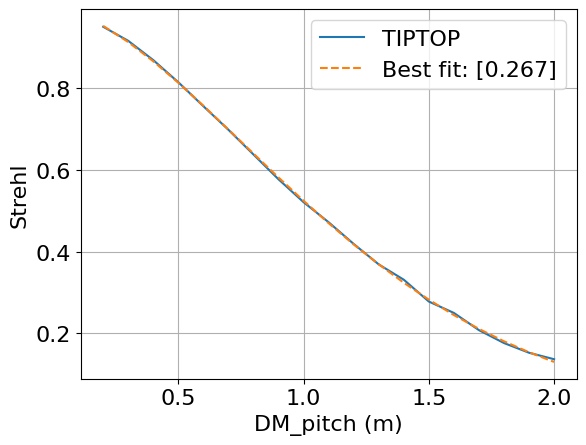

In [5]:
# CALIBRATION OF THE GEOMETRIC ERROR #
######################################

##### Parameters #####
# File parameter
name_error = 'geom'
coeff_0 = [0.5]

# Loop on the actuator pitch accross the pupil
if flag_mode[4:7] == 'VIS':
    var_min = 0.2
    var_max = 2.0
    var_delta = 0.1
elif flag_mode[4:7] == 'IR':
    var_min = 0.9
    var_max = 2.0
    var_delta = 0.1
else:
    raise ValueError(flag_mode + \
        ' -> Unknown mode (*_VIS / *_IR)')  

var_nb = round((var_max-var_min)/var_delta+1)
list_val = np.zeros([var_nb, 1])
list_val[:,0] = np.linspace(var_min, var_max, var_nb)

# zenith_angle = 60.0

def update_config(config, var):
    config['DM']['NumberActuators'] = '[%i]'\
        %(np.floor(eval(config['telescope']['TelescopeDiameter'])/var)+1)
    config['DM']['DmPitchs'] = '[%f]'%(var)

    # Setting other error terms to 0
    config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
    config['sensor_HO']['NumberPhotons'] = '[%s]'%(10000)
    # config['telescope']['ZenithAngle'] = '%f'%(zenith_angle)
    # 1/np.cos(np.radians(zenith_angle))
    config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
    config['atmosphere']['WindSpeed'] = '[0.01]'
    # config['sensor_HO']['NumberLenslets'] = '[%i]' \
    #     %(np.floor(eval(config['telescope']['TelescopeDiameter'])/var)+1)
    return config

x_label = ['DM_pitch (m)']
##### Parameters #####


##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_geom(coeff, airmass, list_val, r_0, lambda_sci), \
    coeff_0, x_label)
print('SR_0: %f'%(SR_0))
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['geom'] = np.array2string(np.append(coeff,SR_0), separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

C:\Users\Anthony\AppData\Local\Temp\ipykernel_70536\786575124.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  config['atmosphere']['WindSpeed'] = '[%f]'%(var)


LO part is not present
******** HO PSD science and NGSs directions
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 127.346754
Required time for AO system model init (ms)	 : 1.998425
Required time for frequency domain init (ms)	 : 77.530146
Required time for final PSD calculation (ms)	 : 43.432951
Required time for WFS reconstructors init (ms)	 : 0.983953
Required time for controller instantiation (ms)	 : 1.006365
Required time for fitting PSD calculation (ms)	 : 2.022028
Required time for aliasing PSD calculation (ms)	 : 40.410995
PSD step: 0.044073971009957816
PSD freq range: 11.2829365785492
PSD shape: (1, 256, 256)
oversampling: 1
sensor_science.PixelScale: 20
******** HO PSF
SR(@ 2200 nm)        : 0.93101
FWHM(@ 2200 nm) [mas]: 58.530
Calculating profile with PSF normalized to total = 1
HO_res [nm]: [93.616]
Output cube shape: (1, 256, 25

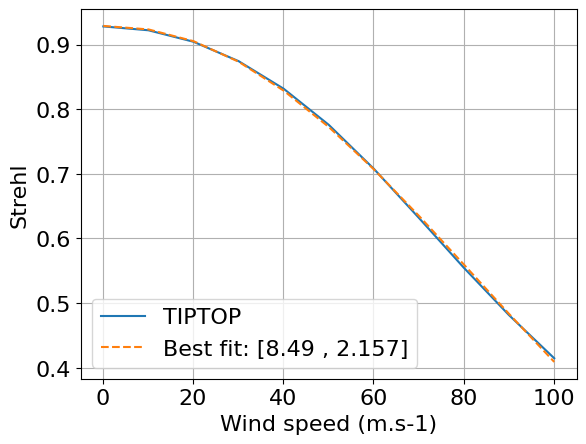

In [6]:
# CALIBRATION OF THE LAG ERROR #
################################

##### Parameters #####
# File parameter
name_error = 'lag'
coeff_0 = [0.5, 2]

# Loop on the wind velocity
var_min = 0.1
var_max = 100.1
var_delta = 10
var_nb = round((var_max-var_min)/var_delta+1)
list_val = np.zeros([var_nb, 1])
list_val[:,0] = np.linspace(var_min, var_max, var_nb)

def update_config(config, var):
    config['atmosphere']['WindSpeed'] = '[%f]'%(var)
    # config['atmosphere']['WindSpeed'] = '[%f, %f]'%(var, -var)
    # config['atmosphere']['Cn2Weights'] = '[0.5, 0.5]'
    # config['atmosphere']['Cn2Heights'] = '[10000.0, 10000.0]'
    # config['atmosphere']['WindDirection'] = '[0.0, 0.0]'
    return config

x_label = ['Wind speed (m.s-1)']
##### Parameters #####


##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_lag(coeff, airmass, list_val, r_0, lambda_sci, f_loop, g_loop), \
    coeff_0, x_label)
print('SR_0: %f'%(SR_0))
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['lag'] = np.array2string(coeff, separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

LO part is not present
******** HO PSD science and NGSs directions
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 134.625435
Required time for AO system model init (ms)	 : 3.000021
Required time for frequency domain init (ms)	 : 73.619366
Required time for final PSD calculation (ms)	 : 55.987120
Required time for WFS reconstructors init (ms)	 : 1.000643
Required time for controller instantiation (ms)	 : 0.999689
Required time for fitting PSD calculation (ms)	 : 2.261639
Required time for aliasing PSD calculation (ms)	 : 49.607515
Required time for ST PSD calculation (ms)	 : 0.733137
PSD step: 0.044073971009957816
PSD freq range: 11.2829365785492
PSD shape: (1, 256, 256)
oversampling: 1
sensor_science.PixelScale: 20
******** HO PSF
SR(@ 2200 nm)        : 0.32112
FWHM(@ 2200 nm) [mas]: 61.688
Calculating profile with PSF normalized to total = 

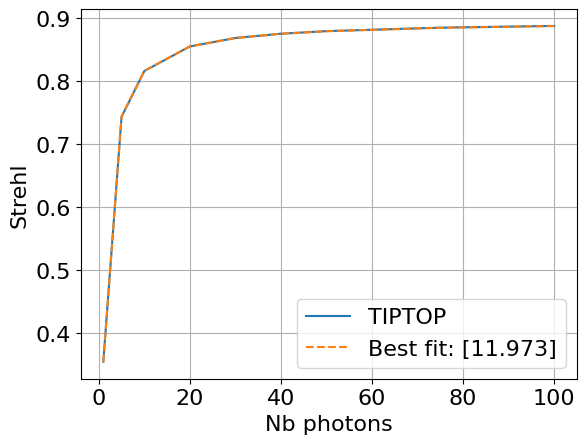

In [7]:
# CALIBRATION OF THE PHOTON NOISE ERROR #
#########################################

##### Parameters #####
# File parameter
name_error = 'photon'
coeff_0 = [0.5]

# Loop on the number of photons
list_val = np.zeros([9, 1])
list_val[:,0] = np.array([1.0,5.0,10.0,20.0,30.0,40.0,50.0,75.0,100.0])

def update_config(config, var):
    config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
    config['sensor_HO']['NumberPhotons'] = '[%s]'%(var)
    return config

x_label = ['Nb photons']
##### Parameters #####

##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_ph(coeff, list_val, lambda_sci, lambda_ngs, g_loop, \
        eval(config_0['sensor_HO']['ExcessNoiseFactor'])), \
    coeff_0, x_label)
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['ph'] = np.array2string(coeff, separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

LO part is not present
******** HO PSD science and NGSs directions


C:\Users\Anthony\AppData\Local\Temp\ipykernel_70536\2940939779.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  config['sensor_HO']['SigmaRON'] = '%f'%(var)


extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 125.885010
Required time for AO system model init (ms)	 : 2.010584
Required time for frequency domain init (ms)	 : 75.615406
Required time for final PSD calculation (ms)	 : 43.977976
Required time for controller instantiation (ms)	 : 1.993656
Required time for fitting PSD calculation (ms)	 : 2.060175
Required time for aliasing PSD calculation (ms)	 : 39.613962
PSD step: 0.044073971009957816
PSD freq range: 11.2829365785492
PSD shape: (1, 256, 256)
oversampling: 1
sensor_science.PixelScale: 20
******** HO PSF
SR(@ 2200 nm)        : 0.89266
FWHM(@ 2200 nm) [mas]: 58.584
Calculating profile with PSF normalized to total = 1
HO_res [nm]: [117.988]
Output cube shape: (1, 256, 256)
LO part is not present
******** HO PSD science and NGSs directions
extra error in nm RMS:  0
extra error spatial frequency

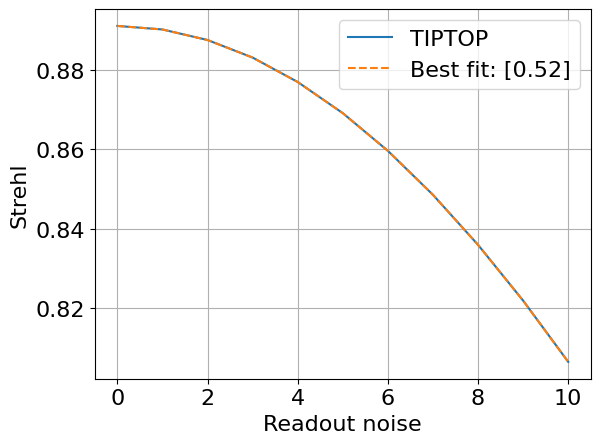

In [8]:
# CALIBRATION OF THE READOUT NOISE ERROR #
##########################################

##### Parameters #####
# File parameter
name_error = 'ron'
coeff_0 = [0.5]

# Loop on the readout noise
var_min = 0.0
var_max = 10.0
var_delta = 1.0
var_nb = round((var_max-var_min)/var_delta+1)
list_val = np.zeros([var_nb, 1])
list_val[:,0] = np.linspace(var_min, var_max, var_nb)

def update_config(config, var):
    config['sensor_HO']['SigmaRON'] = '%f'%(var)
    return config

x_label = ['Readout noise']
##### Parameters #####

##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_ron(coeff, list_val, \
        eval(config_0['sensor_HO']['NumberPhotons'])[0], \
        eval(config_0['sensor_HO']['PixelScale'])/1000, \
        eval(config_0['sensor_HO']['FieldOfView']), \
        g_loop), \
    coeff_0, x_label)
print('SR_0: %f'%(SR_0))
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['ron'] = np.array2string(coeff, separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

LO part is not present
******** HO PSD science and NGSs directions


C:\Users\Anthony\AppData\Local\Temp\ipykernel_70536\3438395336.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  config['sources_science']['Zenith'] = '[%f]'%(var)


extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 155.986547
Required time for AO system model init (ms)	 : 3.361702
Required time for frequency domain init (ms)	 : 89.838505
Required time for final PSD calculation (ms)	 : 59.134960
Required time for WFS reconstructors init (ms)	 : 0.999212
Required time for controller instantiation (ms)	 : 3.000021
Required time for fitting PSD calculation (ms)	 : 2.003193
Required time for aliasing PSD calculation (ms)	 : 54.943562
PSD step: 0.044073971009957816
PSD freq range: 11.2829365785492
PSD shape: (1, 256, 256)
oversampling: 1
sensor_science.PixelScale: 20
******** HO PSF
SR(@ 2200 nm)        : 0.38110
FWHM(@ 2200 nm) [mas]: 59.955
Calculating profile with PSF normalized to total = 1
HO_res [nm]: [343.906]
Output cube shape: (1, 256, 256)
LO part is not present
******** HO PSD science and NGSs directi

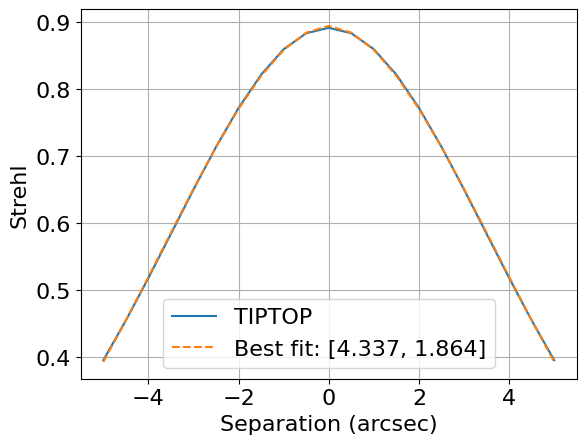

In [9]:
# CALIBRATION OF THE ISOPLANETISM ERROR #
#########################################

##### Parameters #####
# File parameter
name_error = 'isopla'
coeff_0 = [0.5, 2]

# Loop on the readout noise
var_min = -5.0
var_max = -var_min
var_delta = .5
var_nb = round((var_max-var_min)/var_delta+1)
list_val = np.zeros([var_nb, 1])
list_val[:,0] = np.linspace(var_min, var_max, var_nb)

def update_config(config, var):
    config['sources_science']['Zenith'] = '[%f]'%(var)
    config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
    return config

x_label = ['Separation (arcsec)']
##### Parameters #####

##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_iso(coeff, airmass, \
        np.abs(list_val), h_0, r_0, lambda_sci), \
    coeff_0, x_label)
print('SR_0: %f'%(SR_0))
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['iso'] = np.array2string(coeff, separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

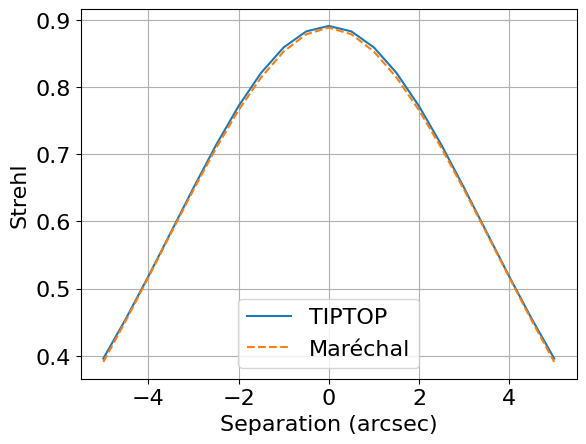

In [10]:
# TESTING MARECHAL APPROXIMATION #
##################################
from astropy.io import fits
import matplotlib.pyplot as plt

# name_error = 'geom'
# x_label = 'DM pitch (m)'
# name_error = 'lag'
# x_label = 'Wind speed (m.s-1)'
# name_error = 'photon'
# x_label = 'Nb photons'
# name_error = 'ron'
# x_label = 'Readout noise'
name_error = 'isopla'
x_label = 'Separation (arcsec)'

# Loading results
path_results_error = path_results + '/' + name_error + '/'

config_0 = configparser.ConfigParser()
config_0.optionxform = str # Needed to be case sensitive
config_0.read(path_results + 'config_0.ini')

list_val = []
dat = fits.getdata(path_results_error + 'list_val.fits')
list_val.append(dat)
list_val = list_val[0]

list_SR_TIPTOP = []
dat = fits.getdata(path_results_error + 'list_SR.fits')
list_SR_TIPTOP.append(dat)
list_SR_TIPTOP = list_SR_TIPTOP[0]

dat = []

# Loop on the configuration files
var_nb = len(list_val)

list_SR_Maréchal = np.zeros(var_nb)
for i in range(var_nb):
    # File suffix
    suf_file = '_%i'%(i)

    # Opening configuration
    config_temp = configparser.ConfigParser()
    config_temp.optionxform = str # Needed to be case sensitive
    config_temp.read(path_results_error + name_error + suf_file + '.ini')

    # Adding the Strehl parameters
    config_temp['Strehl']['geom'] = config_0['Strehl']['geom'] 
    config_temp['Strehl']['lag'] = config_0['Strehl']['lag'] 
    config_temp['Strehl']['ph'] = config_0['Strehl']['ph'] 
    config_temp['Strehl']['ron'] = config_0['Strehl']['ron'] 
    config_temp['Strehl']['iso'] = config_0['Strehl']['iso']

    # Saving temporary configuration
    with open(path_results + 'config_temp.ini', 'w') \
        as configfile: config_temp.write(configfile)

    # Running Maréchal approximation
    list_SR_Maréchal[i] = fit_tiptop.compute_Maréchal_NGS(path_results, 'config_temp')

    # Removing temporary file
    os.remove(path_results + 'config_temp.ini')

# Display
plt.figure(0)
plt.clf()
plt.plot(list_val, list_SR_TIPTOP, label = 'TIPTOP')
plt.plot(list_val, list_SR_Maréchal, label = 'Maréchal', linestyle = 'dashed')
plt.xlabel(x_label)
plt.ylabel('Strehl')
plt.grid()
plt.legend()

C:\Users\Anthony\AppData\Local\Temp\ipykernel_70536\1831521235.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  config['sources_science']['Wavelength'] = '[%e]'%(var/10**6)
C:\Users\Anthony\AppData\Local\Temp\ipykernel_70536\1831521235.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  config['sensor_science']['PixelScale'] = '%f'%(var/8e6*180/np.pi*3600*1000/4)


LO part is not present
******** HO PSD science and NGSs directions
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 464.265347
Required time for AO system model init (ms)	 : 2.991199
Required time for frequency domain init (ms)	 : 155.847073
Required time for final PSD calculation (ms)	 : 284.003735
Required time for WFS reconstructors init (ms)	 : 1.990318
Required time for controller instantiation (ms)	 : 3.001928
Required time for fitting PSD calculation (ms)	 : 11.057615
Required time for aliasing PSD calculation (ms)	 : 265.947819
Required time for noise PSD calculation (ms)	 : 1.013756
PSD step: 0.03125000390167501
PSD freq range: 16.000001997657606
PSD shape: (1, 512, 512)
oversampling: 1
sensor_science.PixelScale: 3.222888
******** HO PSF
SR(@ 500 nm)        : 0.09125
FWHM(@ 500 nm) [mas]: 13.708
Calculating profile with PSF normalized

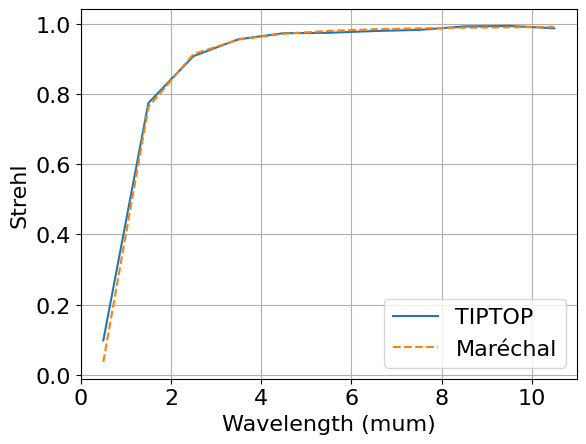

In [11]:
# TESTING MARECHAL APPROXIMATION ON OTHER PARAMETERS #
######################################################

# Python
import os
import numpy as np
import configparser

from astropy.io import fits
import matplotlib.pyplot as plt

# Tiptop
import importlib
import importlib as importlib
importlib.reload(fit_tiptop)

##### Parameters #####

# Global paths

path = os.getcwd() + '/'
flag_mode = 'NGS_VIS' # NGS_VIS/NGS_IR
path_config_0 = path + 'config/'
path_results = path + 'results/Maréchal_calibration/' + flag_mode + '/'

# Error type
name_error = 'wavelength_sci'

if name_error == 'Zenith':
    # Loop on the zenith angle
    x_label = 'Zenith angle (deg)'

    var_min = 0
    var_max = 70
    var_delta = 10
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['telescope']['ZenithAngle'] = '%f'%(var)

        # config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
        # config['atmosphere']['WindSpeed'] = '[0.0001]'
        # config['atmosphere']['WindDirection'] = '[0.0]'
        # config['sensor_HO']['NumberPhotons'] = '[100000]'
        # config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
        # config['sources_science']['Zenith'] = '[0.0]'

        # config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
        # config['atmosphere']['WindSpeed'] = '[75]'
        # config['atmosphere']['WindDirection'] = '[0.0]'
        # config['sensor_HO']['NumberPhotons'] = '[100000]'
        # config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
        # config['sources_science']['Zenith'] = '[0.0]'

        config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
        config['atmosphere']['WindSpeed'] = '[0.0001]'
        config['atmosphere']['WindDirection'] = '[0.0]'
        config['sensor_HO']['NumberPhotons'] = '[100000]'
        config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
        config['sources_science']['Zenith'] = '[5.0]'
        
        # config['DM']['NumberActuators'] = '[%i]'\
        #     %(np.floor(eval(config['telescope']['TelescopeDiameter'])/0.15)+1)
        # config['DM']['DmPitchs'] = '[%f]'%(0.15)
        # config['sensor_science']['FieldOfView'] = '512'
        # config['sensor_science']['PixelScale'] = '%f'%(40)
        
        return config

elif name_error == 'wavelength_sci':
    # Loop on the wavelength
    x_label = 'Wavelength (mum)'

    var_min = 0.500
    var_max = 10.5
    var_delta = 1.0
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['sources_science']['Wavelength'] = '[%e]'%(var/10**6)
        # config['telescope']['ZenithAngle'] = '%f'%(35.0)
        config['telescope']['TechnicalFoV'] = '240'
        config['sensor_science']['PixelScale'] = '%f'%(var/8e6*180/np.pi*3600*1000/4)
        config['sensor_science']['FieldOfView'] = '512'

        # config['sensor_HO']['NumberPhotons'] = '[10]'
        
        # config['atmosphere']['WindSpeed'] = '[75]'

        return config

elif name_error == 'wavelength_ngs':
    # Loop on the wavelength
    x_label = 'Wavelength NGS (mum)'

    var_min = 0.500
    var_max = 3.0
    var_delta = 0.5
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['sources_HO']['Wavelength'] = '[%e]'%(var/10**6)

        return config

elif name_error == 'g_loop':
    # Loop on the gain
    x_label = 'Loop gain'

    var_min = 0.1
    var_max = 0.9
    var_delta = 0.05
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['RTC']['LoopGain_HO'] = '%f'%(var)
        # config['telescope']['ZenithAngle'] = '%f'%(35.0)
        # config['sensor_HO']['SigmaRON'] = '1'
        # config['atmosphere']['WindSpeed'] = '[0.1]'
        # config['sensor_HO']['NumberPhotons'] = '[10]'
        config['atmosphere']['WindSpeed'] = '[35]'
        config['sensor_HO']['NumberPhotons'] = '[200]'
        return config

elif name_error == 'turb_layer':
    # Loop on the gain
    x_label = 'Mixing coefficient'

    var_min = 0.0
    var_max = 1.0
    var_delta = 0.1
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['atmosphere']['Cn2Weights'] = '[%f, %f]'%(1-var, var)

        # config['atmosphere']['WindSpeed'] = '[35, 100]'
        # config['atmosphere']['Cn2Heights'] = '[7500, 7500]'
        # config['atmosphere']['WindDirection'] = '[0.0, 0.0]'
        # config['sources_science']['Zenith'] = '[0.0]'
        
        # config['atmosphere']['WindSpeed'] = '[35, 35]'
        # config['atmosphere']['Cn2Heights'] = '[7500, 12500]'
        # config['atmosphere']['WindDirection'] = '[0.0, 0.0]'
        # config['sources_science']['Zenith'] = '[3.0]'

        config['atmosphere']['WindSpeed'] = '[35, 100]'
        config['atmosphere']['Cn2Heights'] = '[7500, 12500]'
        config['atmosphere']['WindDirection'] = '[0.0, 0.0]'
        config['sources_science']['Zenith'] = '[3.0]'
        
        return config

elif name_error == 'pix_scale':
    # Loop on the gain
    x_label = 'Pixel scale'

    var_min = 100
    var_max = 2000
    var_delta = 100
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['sensor_HO']['PixelScale'] = '%f'%(var)
        return config

elif name_error == 'N_pix':
    # Loop on the gain
    x_label = 'Number of pixels'

    var_min = 6
    var_max = 12
    var_delta = 1
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['sensor_HO']['FieldOfView'] = '%f'%(var)
        return config

elif name_error == 'freq':
    # Loop on the gain
    x_label = 'Loop frequency'

    var_min = 100
    var_max = 1000
    var_delta = 100
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['RTC']['SensorFrameRate_HO'] = '%f'%(var)
        return config


else:
    raise ValueError('Unknown error')  


##### Parameters #####


##### Simulation #####
list_SR_TIPTOP = fit_tiptop.run_simu( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    x_label)
##### Simulation #####



##### Maréchal #####
path_results_error = path_results + '/' + name_error + '/'
list_SR_Maréchal = np.zeros(var_nb)
for i in range(var_nb):
    # File suffix
    suf_file = '_%i'%(i)

    # Running Maréchal approximation
    list_SR_Maréchal[i] = fit_tiptop.compute_Maréchal_NGS(path_results_error, name_error + suf_file)
##### Maréchal #####

# Display
plt.figure(0)
plt.clf()
plt.plot(list_val, list_SR_TIPTOP, label = 'TIPTOP')
plt.plot(list_val, list_SR_Maréchal, label = 'Maréchal', linestyle = 'dashed')
plt.xlabel(x_label)
plt.ylabel('Strehl')
plt.grid()
plt.legend()


In [12]:
# ###############################################
# # CALIBRATION OF THE GEOMETRIC ERROR (secant) #
# ###############################################
# # Tiptop
# import importlib
# import aspro
# importlib.reload(aspro)

# ##### Parameters #####
# # File parameter
# name_error = 'secant'

# # Loop on the actuator pitch accross the pupil
# var_min = 0
# var_max = 60
# var_delta = 10
# var_nb = round((var_max-var_min)/var_delta+1)
# list_val = np.linspace(var_min, var_max, var_nb)

# def update_config(config, var):


#     config['telescope']['ZenithAngle'] = '%f'%(var)
#     # config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
#     config['atmosphere']['WindSpeed'] = '[0.1]'
#     config['sensor_HO']['NumberPhotons'] = '[100000]'

    
#     return config

# x_label = 'Zenith angle secant'
# ##### Parameters #####


# ##### Simulation and fitting #####
# coeff_0 = [0.5, 2]
# [SR, coeff, SR_0] = fit_tiptop.calib_error( \
#     path_results, name_error, list_val, \
#     lambda config, var:update_config(config, var), \
#     lambda coeff, list_val:aspro.Strehl_geom(coeff, 1/np.cos(np.radians(list_val)), eval(config_0['DM']['DmPitchs'])[0], r_0, lambda_sci), \
#     coeff_0, x_label)
# ##### Simulation and fitting #####

# ##### Storing and saving ######
# config_0['Strehl']['geom'] = np.array2string(coeff, separator=', ')
# with open(path_results + 'config_0.ini', 'w') \
#     as configfile: config_0.write(configfile)
# ##### Storing and saving ######